In [7]:
# ESTAS 4 son ESENCIALES:
import seaborn as sns    
import matplotlib.pyplot as plt  
import pandas as pd         
import numpy as np        


from matplotlib.patches import Patch  

In [ ]:
# 1. Leer archivos
counts_df = pd.read_csv("data/counts/counts_for_DEA.csv")      #  Conteos de genes
design_df = pd.read_csv("data/metadata/design_matrix.csv")     #  Condiciones experimentales

C:\Users\yeimi\AppData\Local\Temp\ipykernel_2016\3208744441.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\yeimi\AppData\Local\Temp\ipykernel_2016\3208744441.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


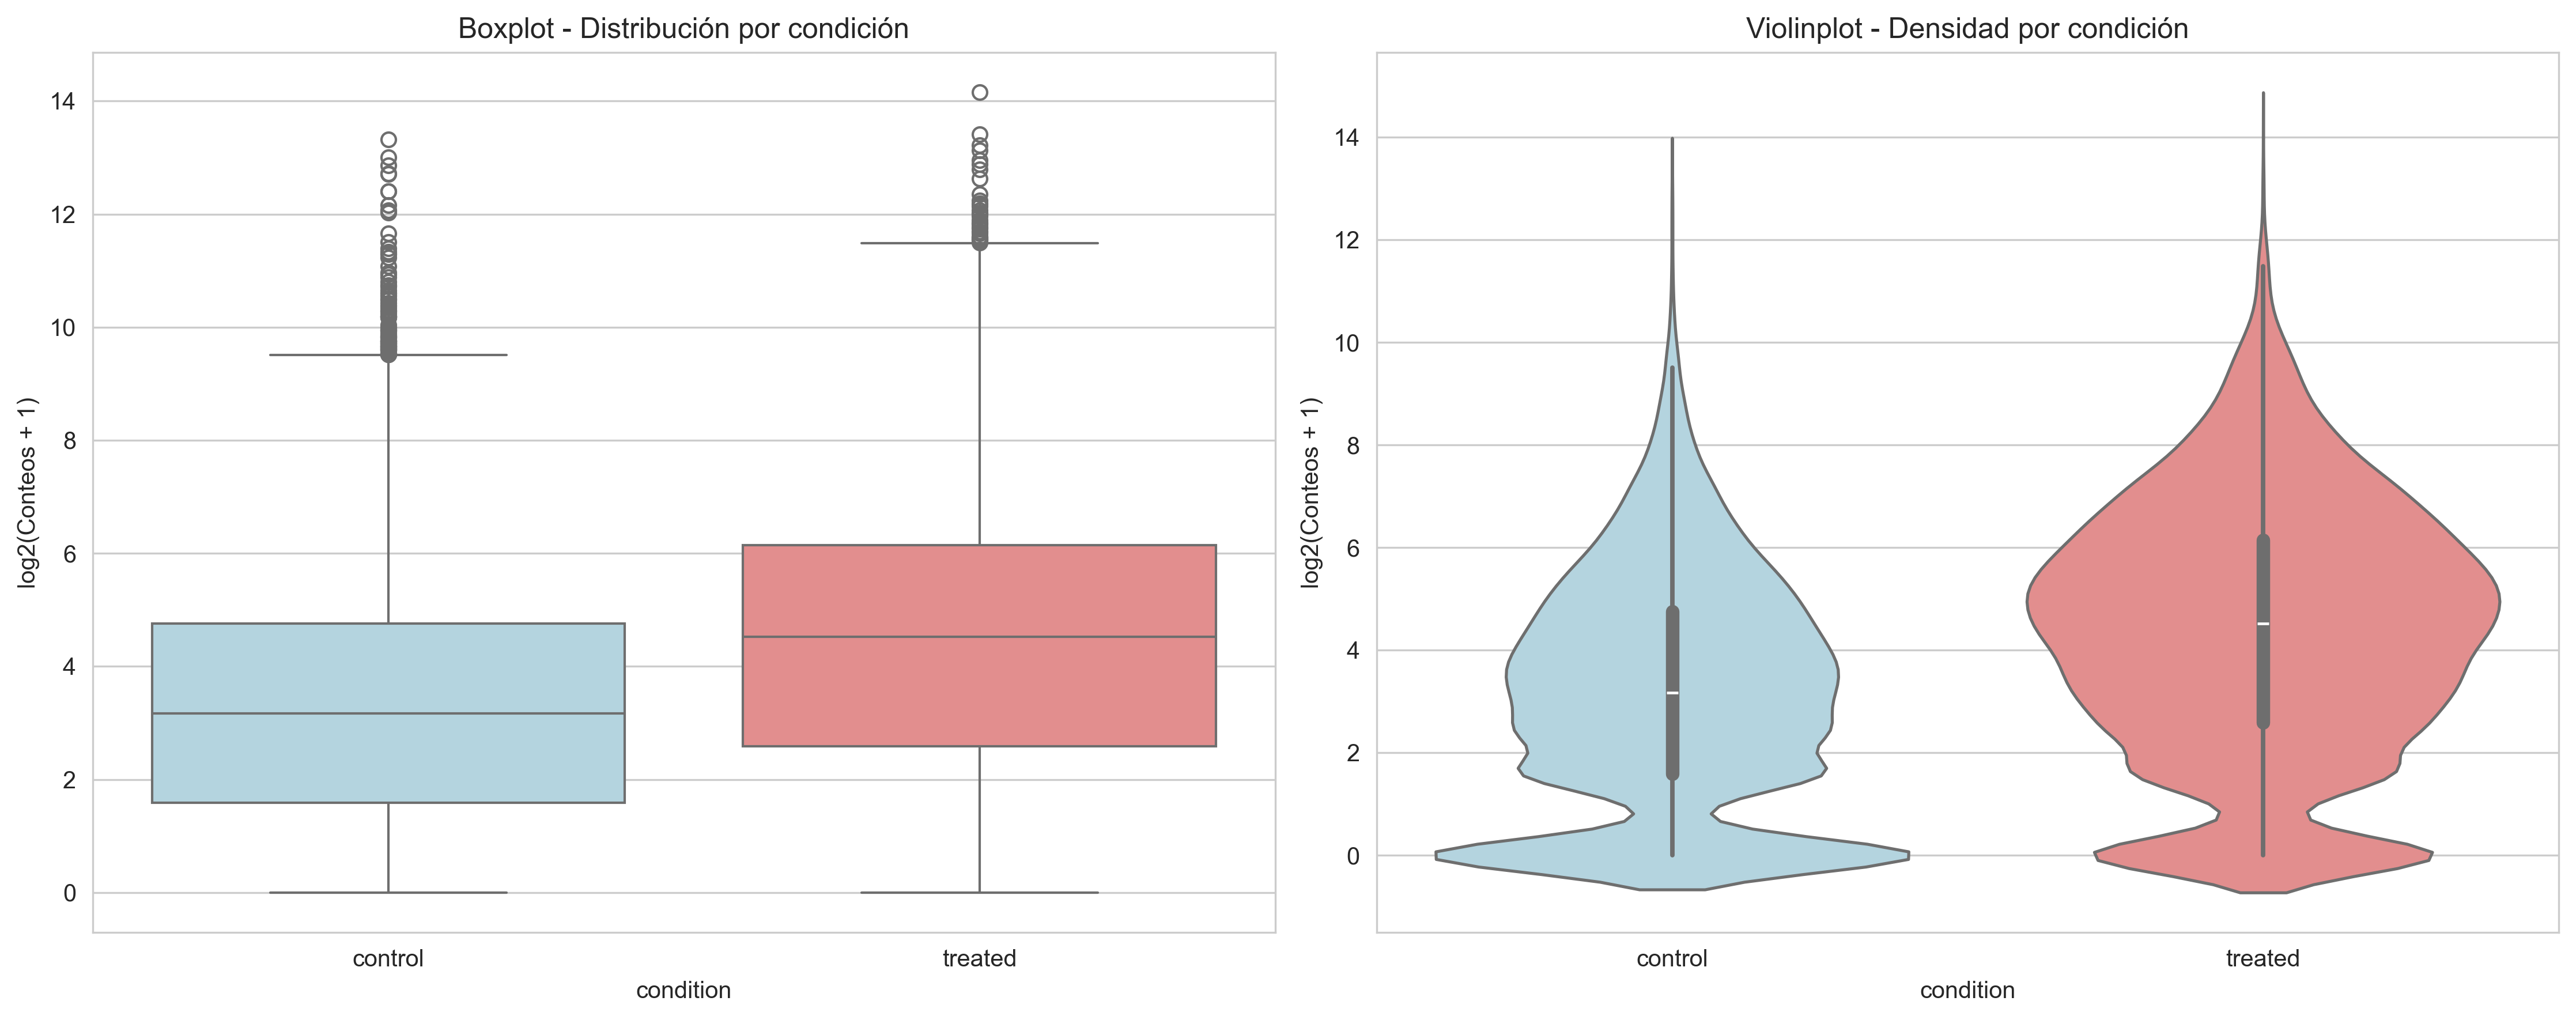

In [11]:

# 2. Revisar nombres de columnas y estandarizar (opcional)
counts_df.columns = counts_df.columns.str.strip()   # quitar espacios
# Si quieres todo en minúsculas:
# counts_df.columns = counts_df.columns.str.lower()

# 3. Reorganizar datos: melt
datos_melted = counts_df.melt(
    id_vars=['Geneid'],   # usa el nombre exacto de la columna
    var_name='sample',
    value_name='count'
)

# 4. Unir con diseño experimental (asegúrate que design_df tenga columna 'sample')
# Si en design_df la columna se llama distinto, renómbrala:
# design_df = design_df.rename(columns={'SampleID': 'sample'})
datos_melted = datos_melted.merge(design_df, on='sample')

# 5. Calcular log2(count+1)
datos_melted['log_count'] = np.log2(datos_melted['count'] + 1)

# 6. Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
sns.boxplot(
    data=datos_melted,
    x='condition',
    y='log_count',
    palette={'control': 'lightblue', 'treated': 'lightcoral'},
    ax=ax1
)
ax1.set_title('Boxplot - Distribución por condición')
ax1.set_ylabel('log2(Conteos + 1)')

# Violinplot
sns.violinplot(
    data=datos_melted,
    x='condition',
    y='log_count',
    palette={'control': 'lightblue', 'treated': 'lightcoral'},
    ax=ax2
)
ax2.set_title('Violinplot - Densidad por condición')
ax2.set_ylabel('log2(Conteos + 1)')

plt.tight_layout()
plt.show()

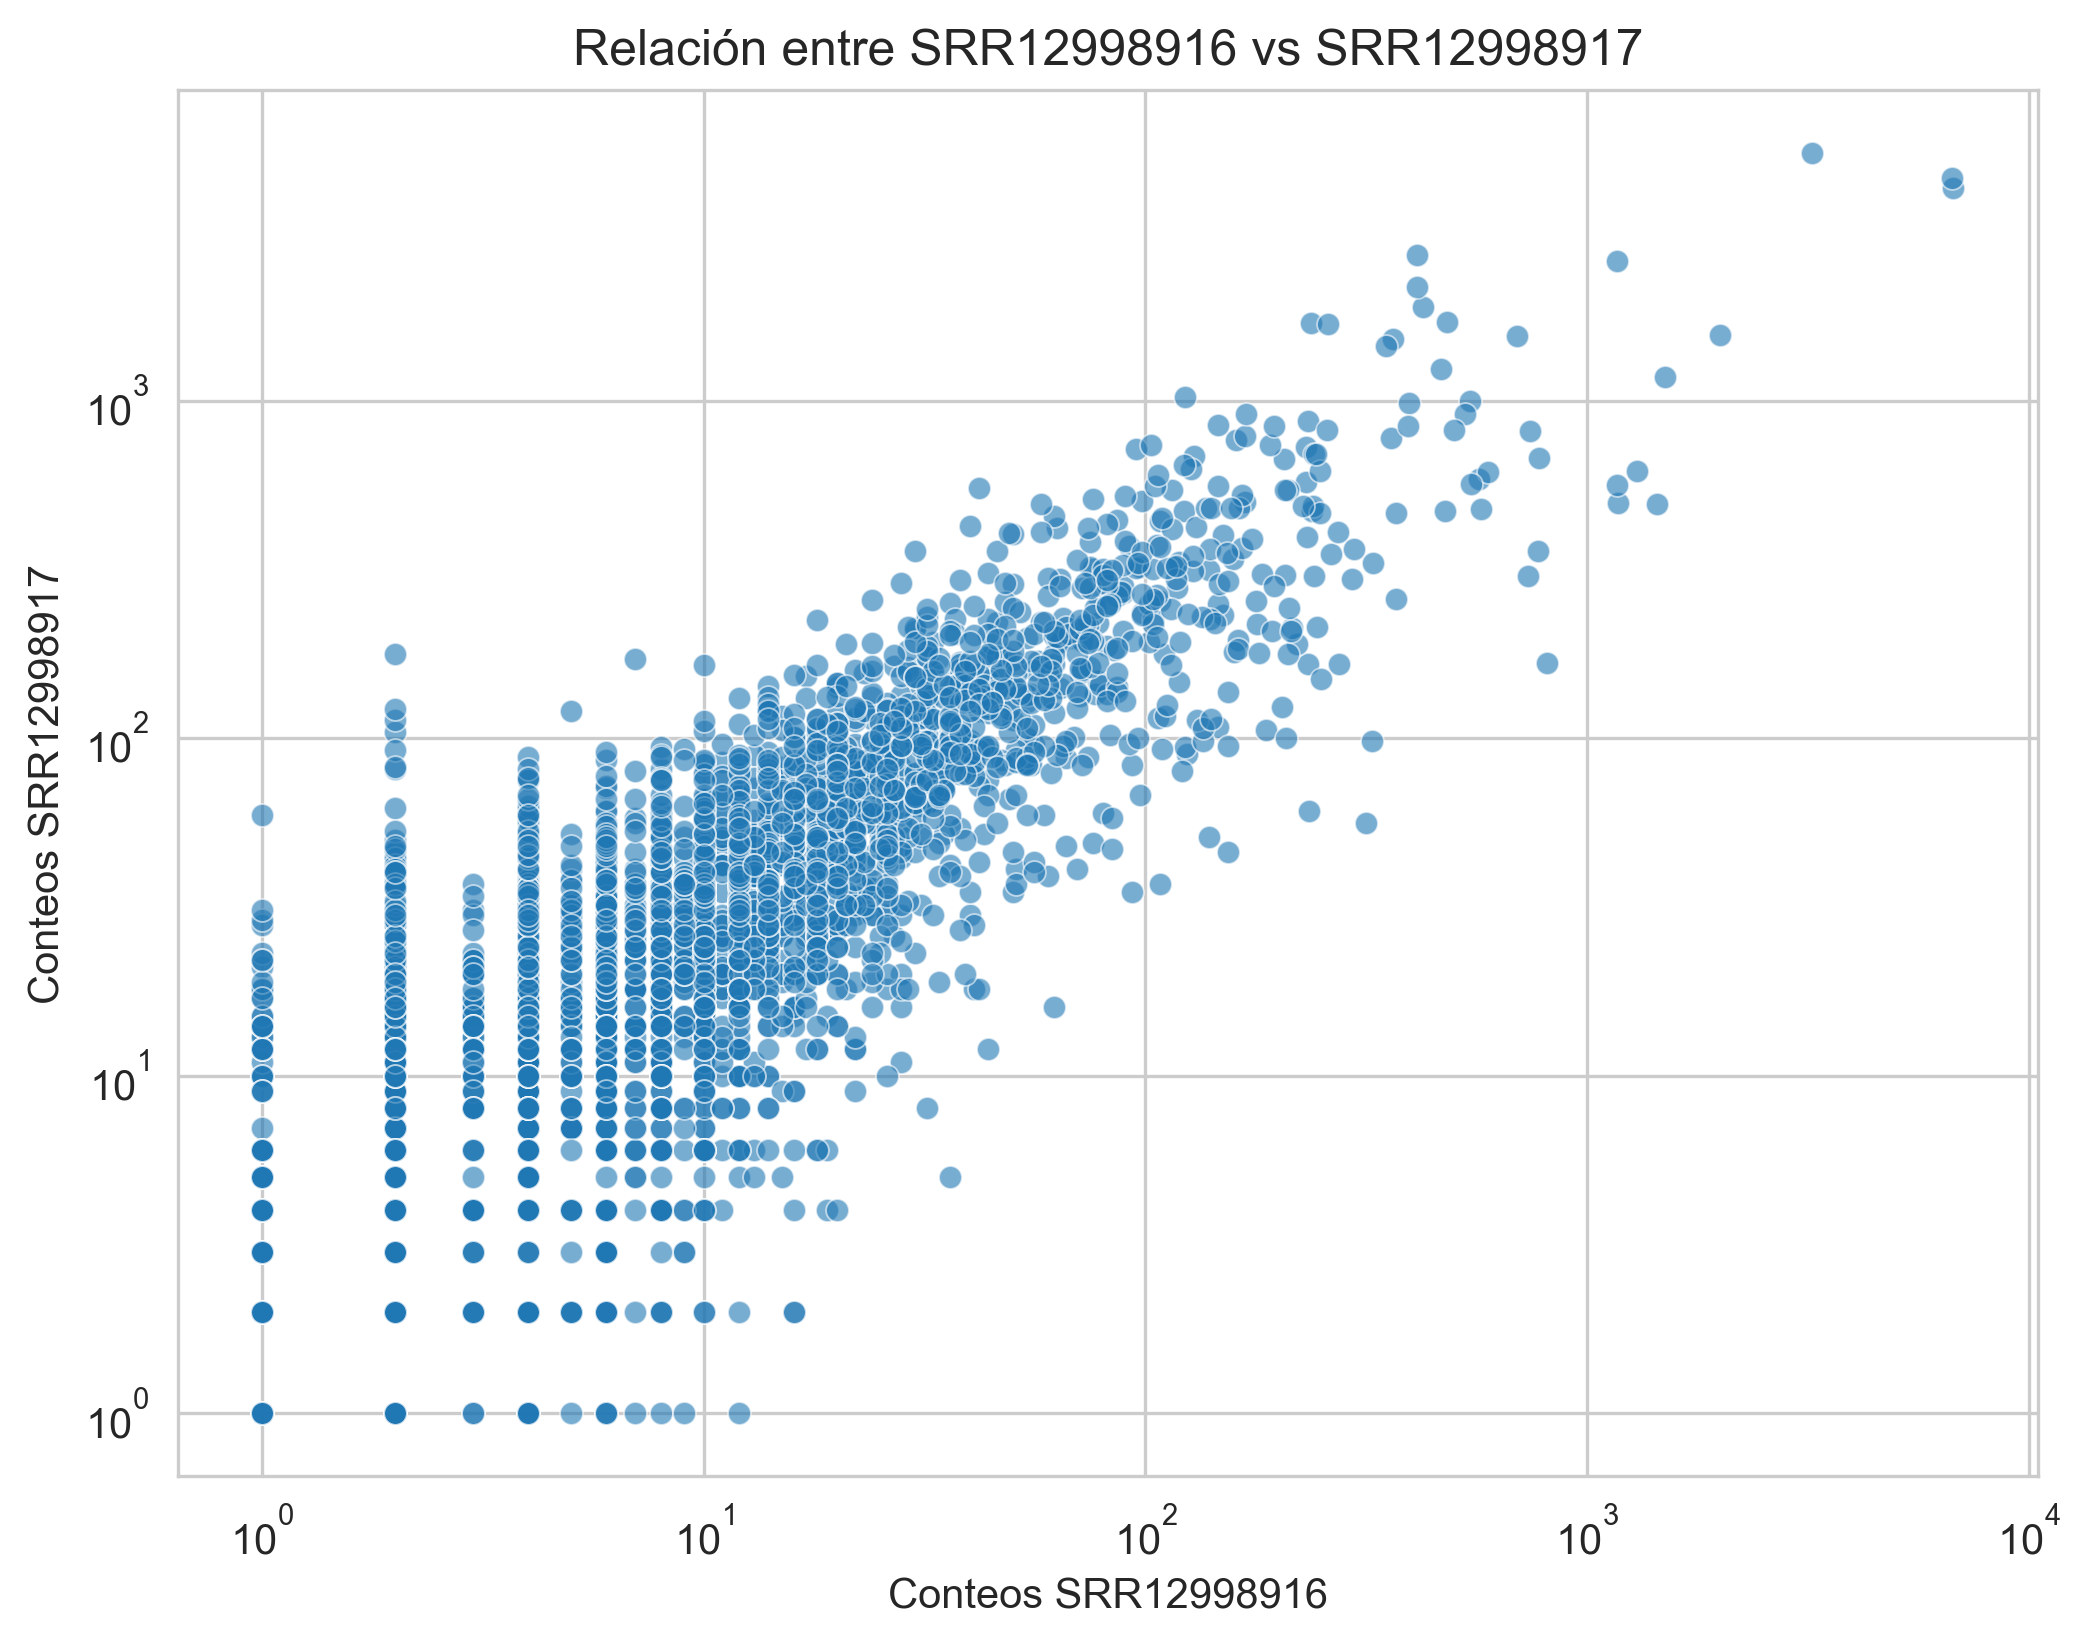

In [16]:

# Preparar datos: expresión de 2 muestras para scatter
muestra1 = counts_df.columns[1]  # Primera muestra
muestra2 = counts_df.columns[2]  # Segunda muestra

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=counts_df,
    x=muestra1,
    y=muestra2,
    alpha=0.6,
    s=30
)
plt.title(f'Relación entre {muestra1} vs {muestra2}')
plt.xlabel(f'Conteos {muestra1}')
plt.ylabel(f'Conteos {muestra2}')
plt.xscale('log')
plt.yscale('log')
plt.show()

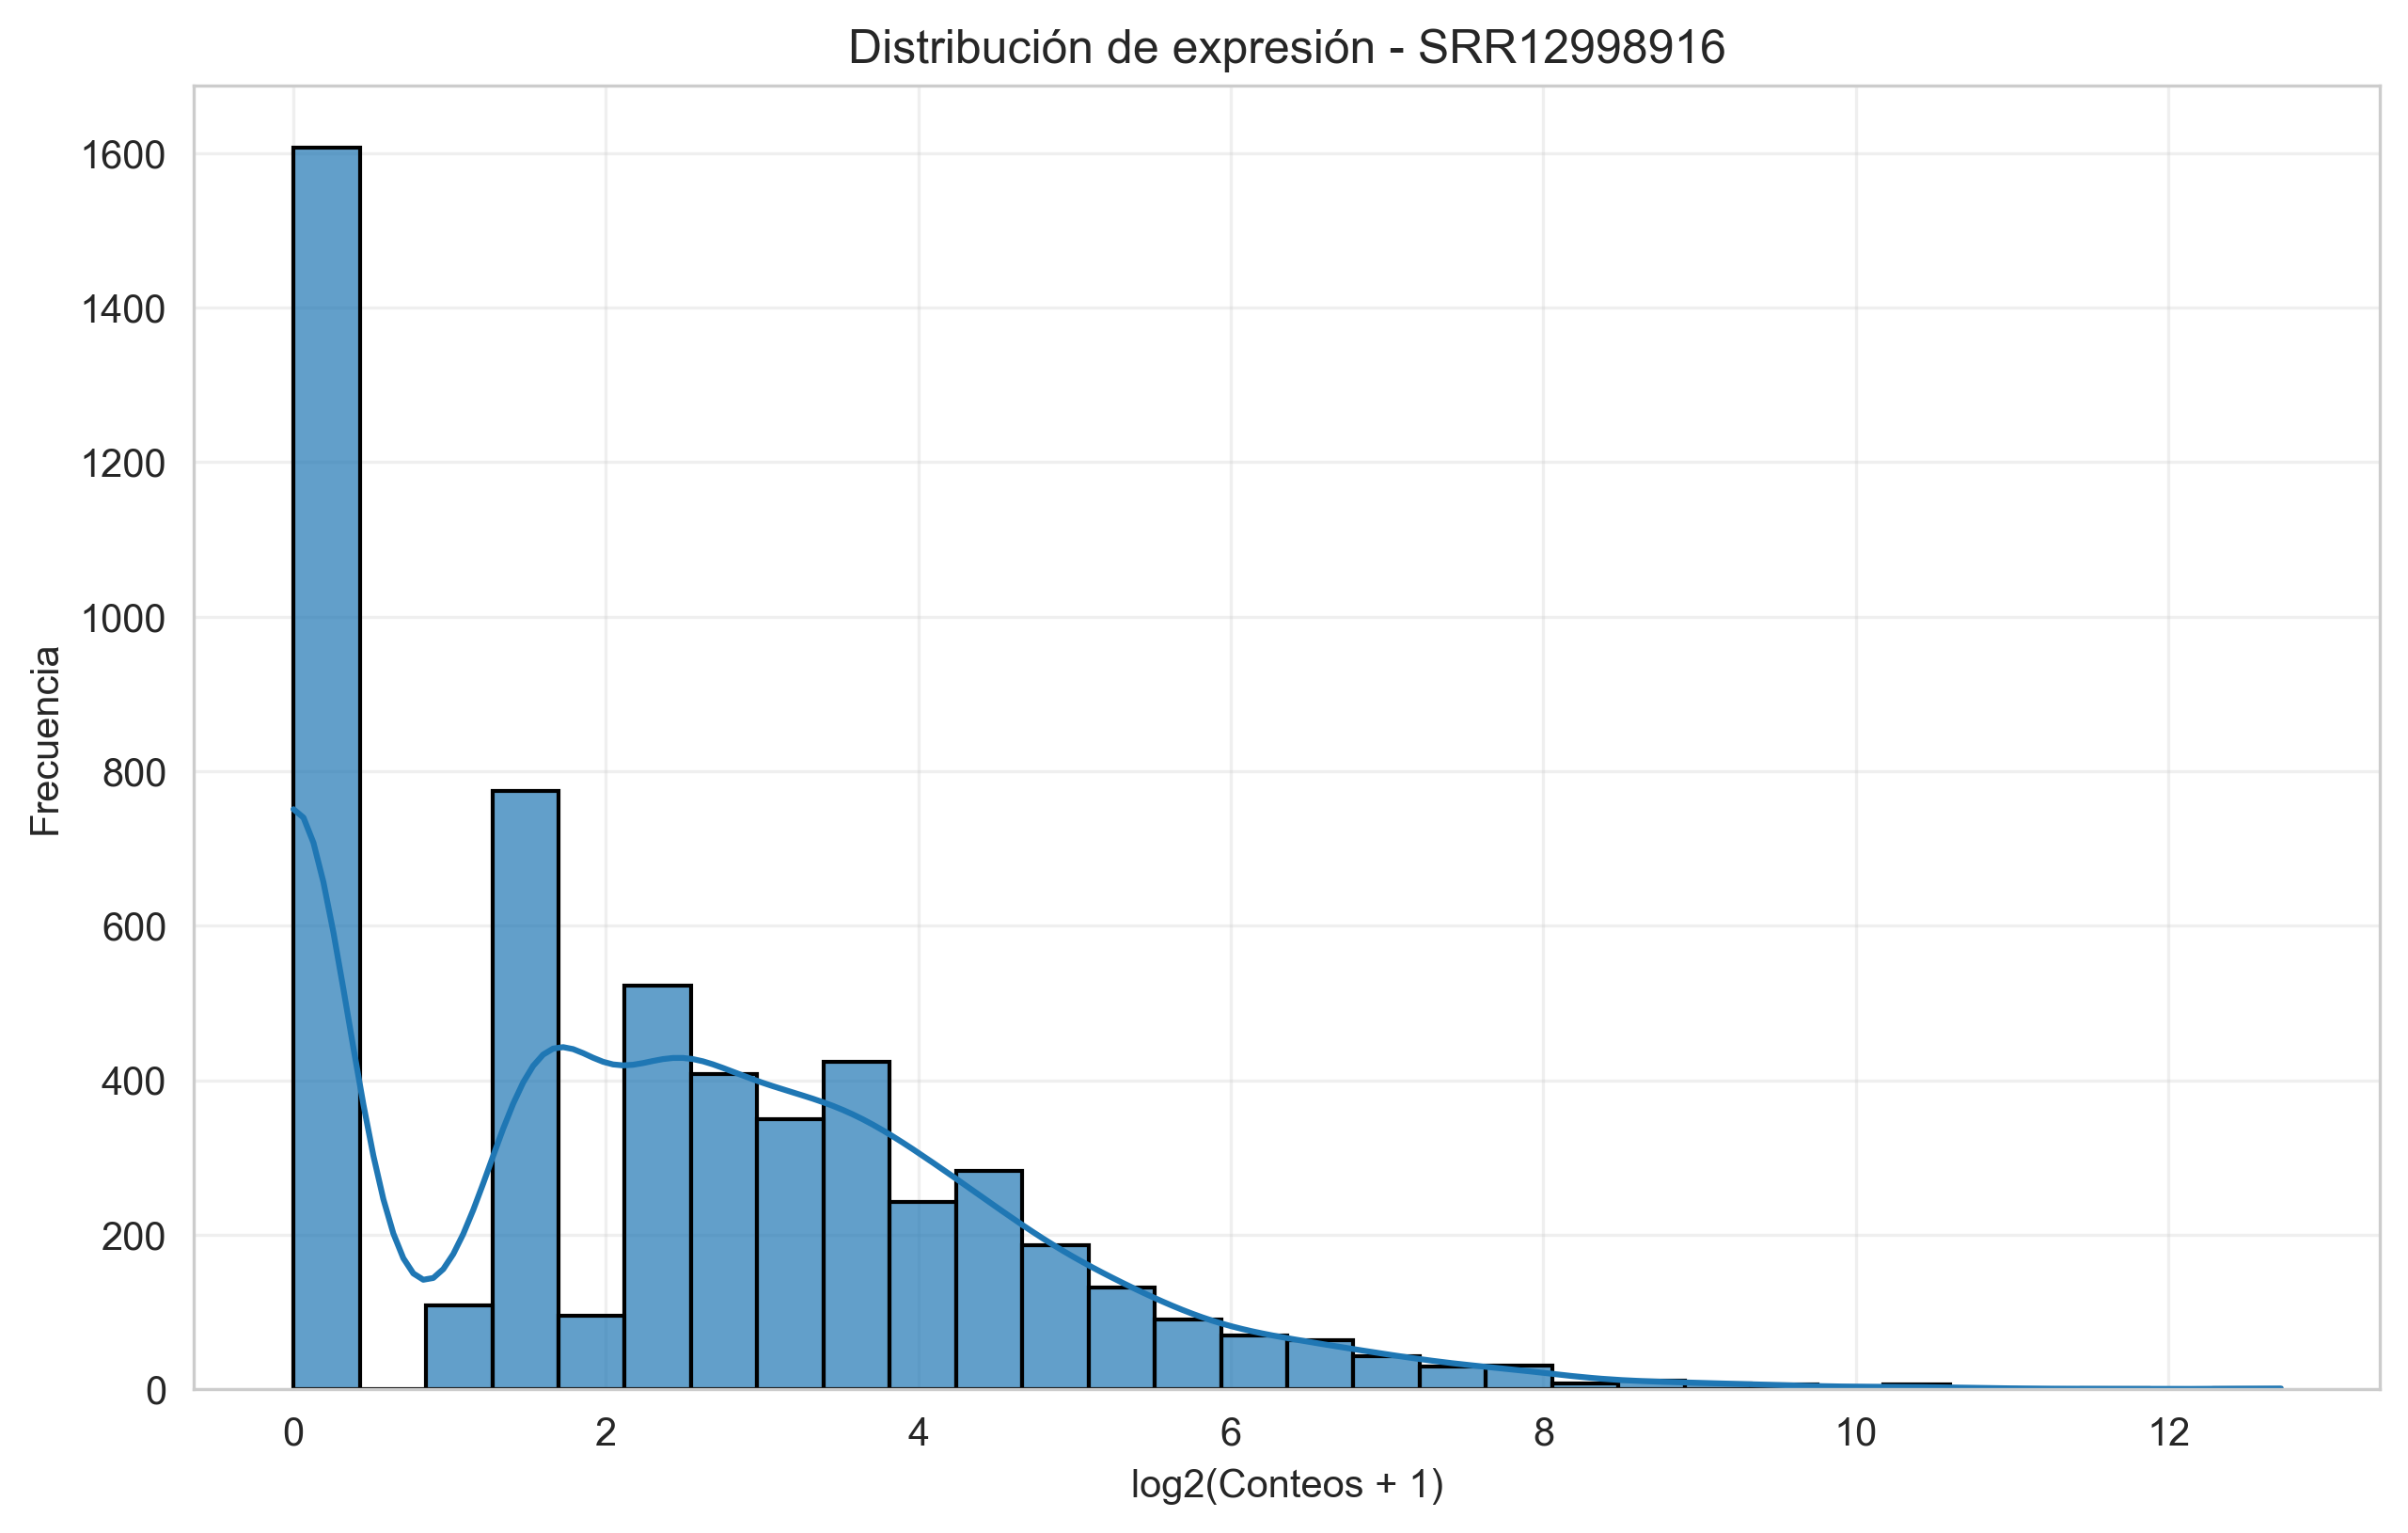

In [18]:

# Tomar una muestra y aplicar log-transform
muestra = counts_df.columns[1]  # Primera muestra
datos = np.log2(counts_df[muestra] + 1)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=datos, 
    kde=True,           # Línea de densidad
    bins=30,            # Número de barras
    alpha=0.7,
    edgecolor='black'
)
plt.title(f'Distribución de expresión - {muestra}')
plt.xlabel('log2(Conteos + 1)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

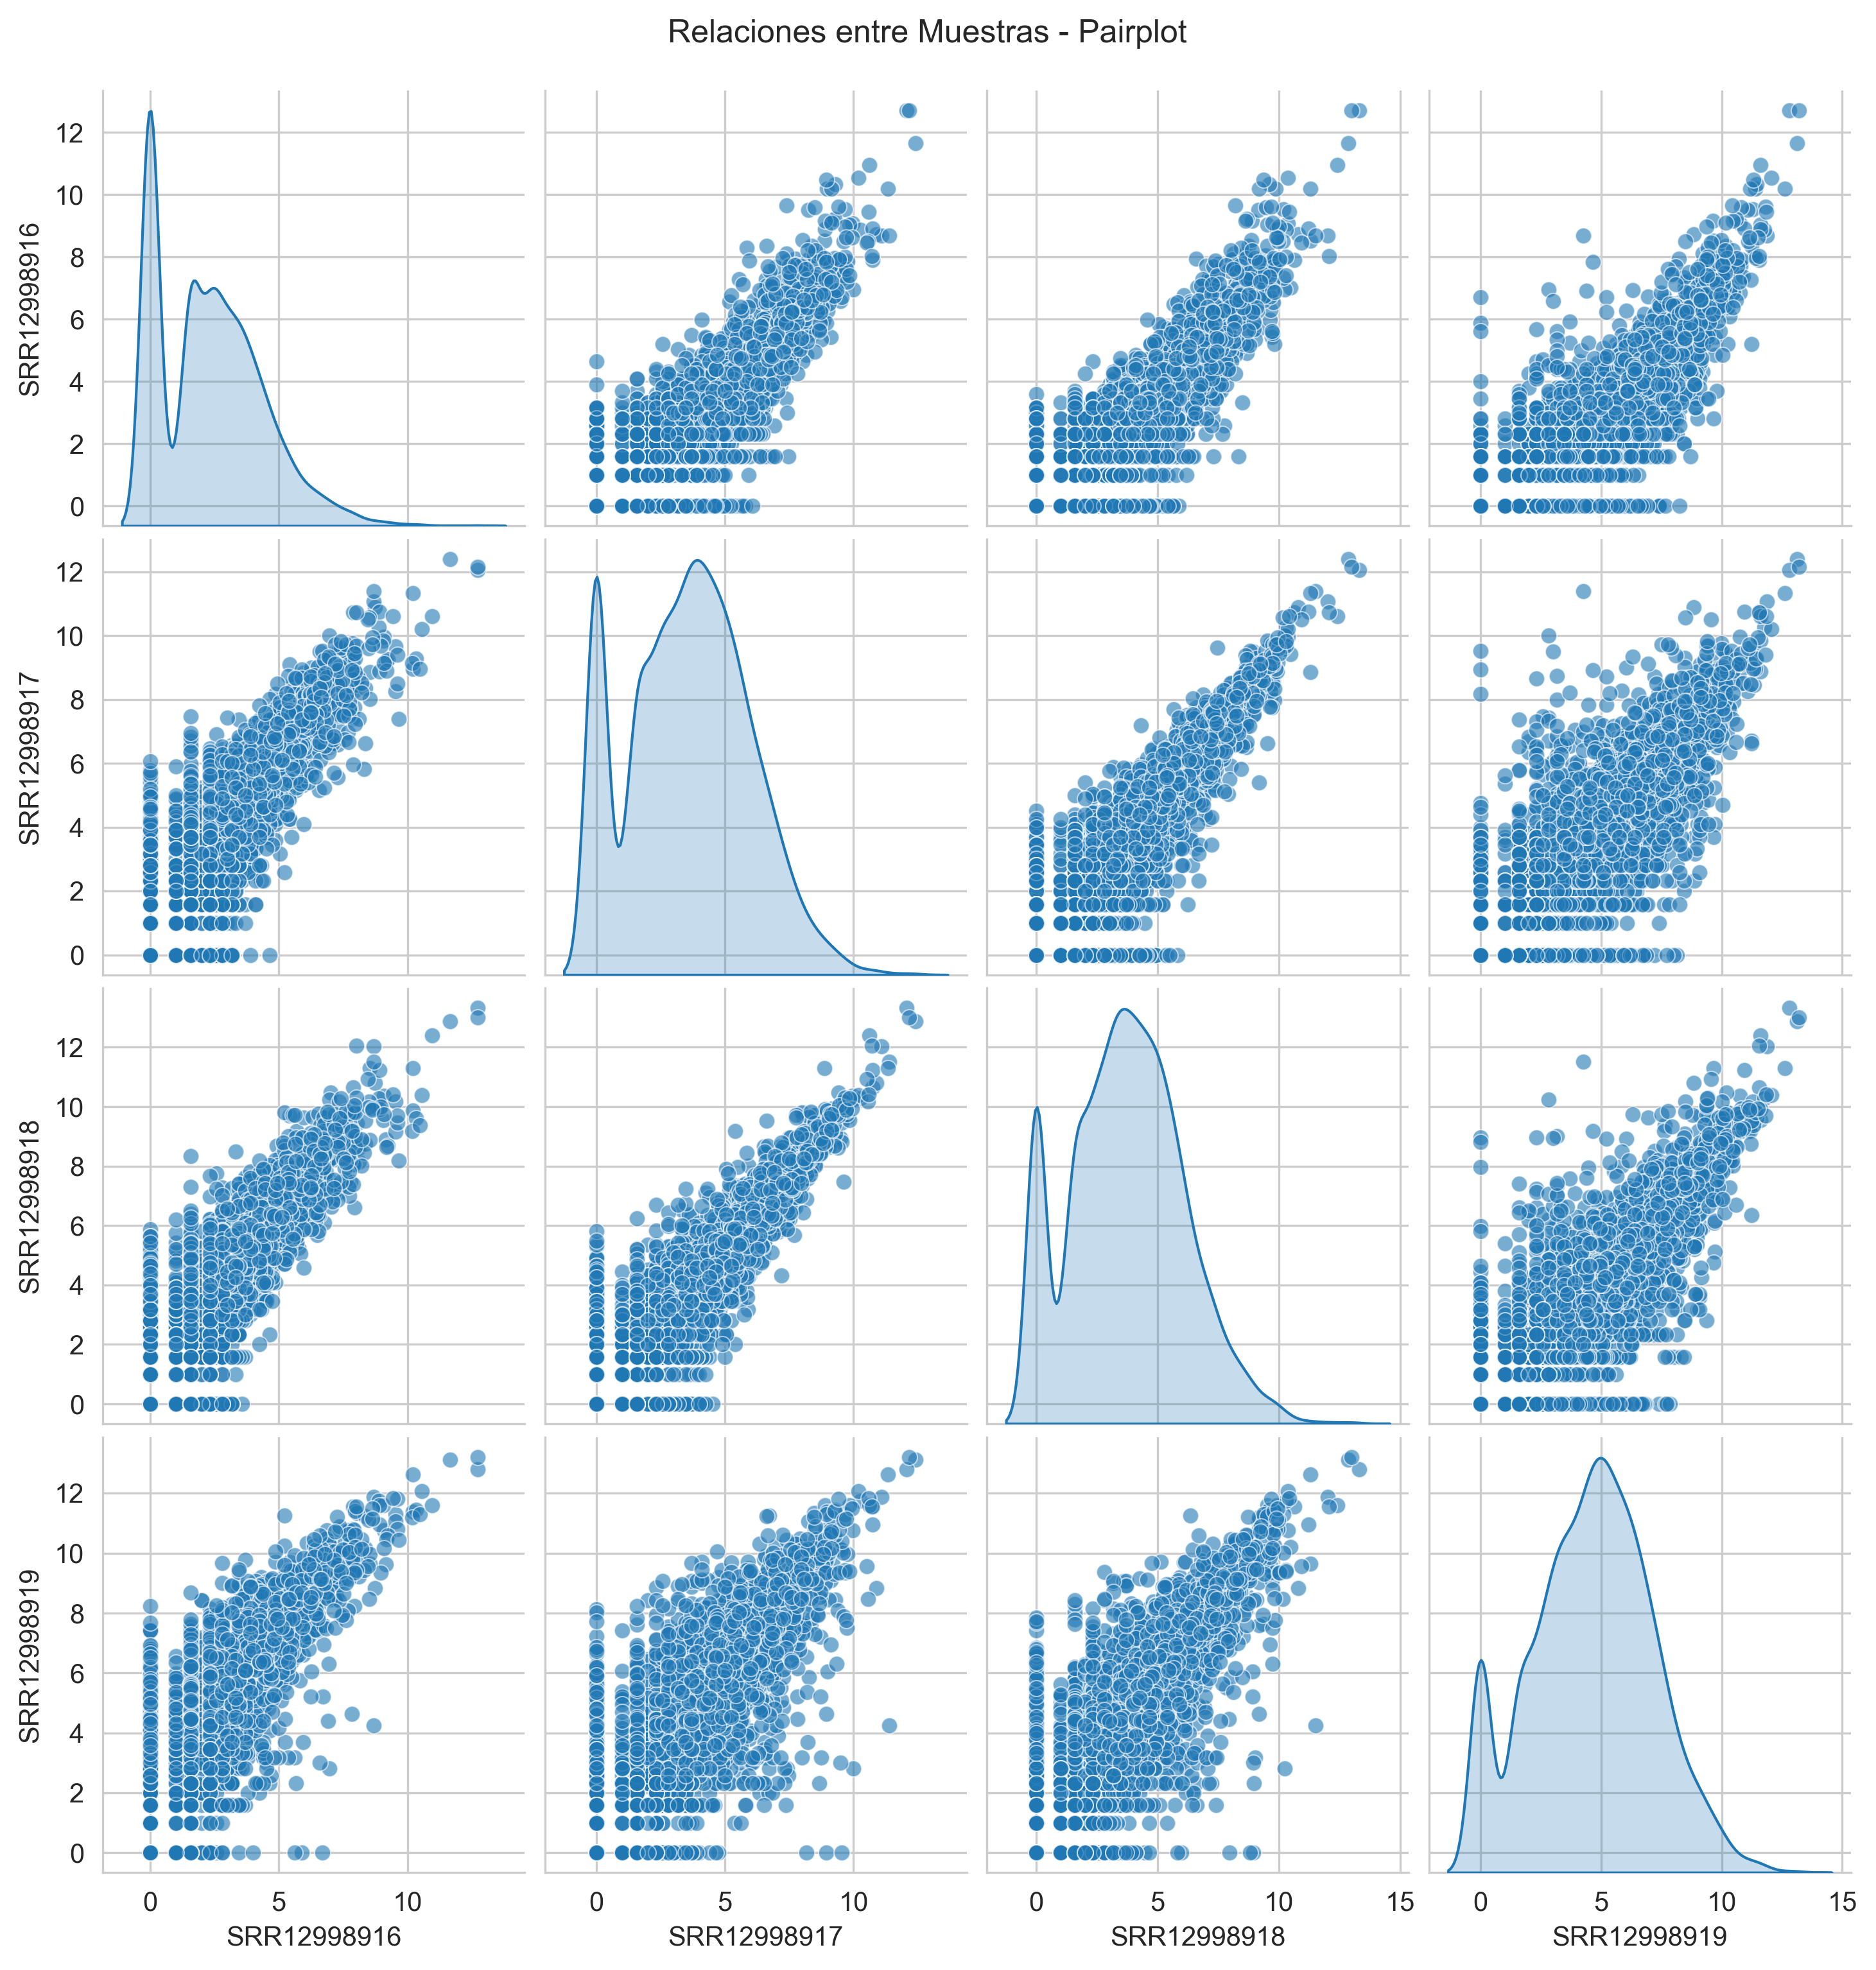

In [20]:

# Tomar solo 4 muestras para no saturar
muestras_subset = counts_df.columns[1:5]  # Primeras 4 muestras
datos_subset = counts_df[muestras_subset]

# Aplicar log-transform
datos_log = np.log2(datos_subset + 1)

# Pairplot
sns.pairplot(datos_log, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Relaciones entre Muestras - Pairplot', y=1.02)
plt.show()

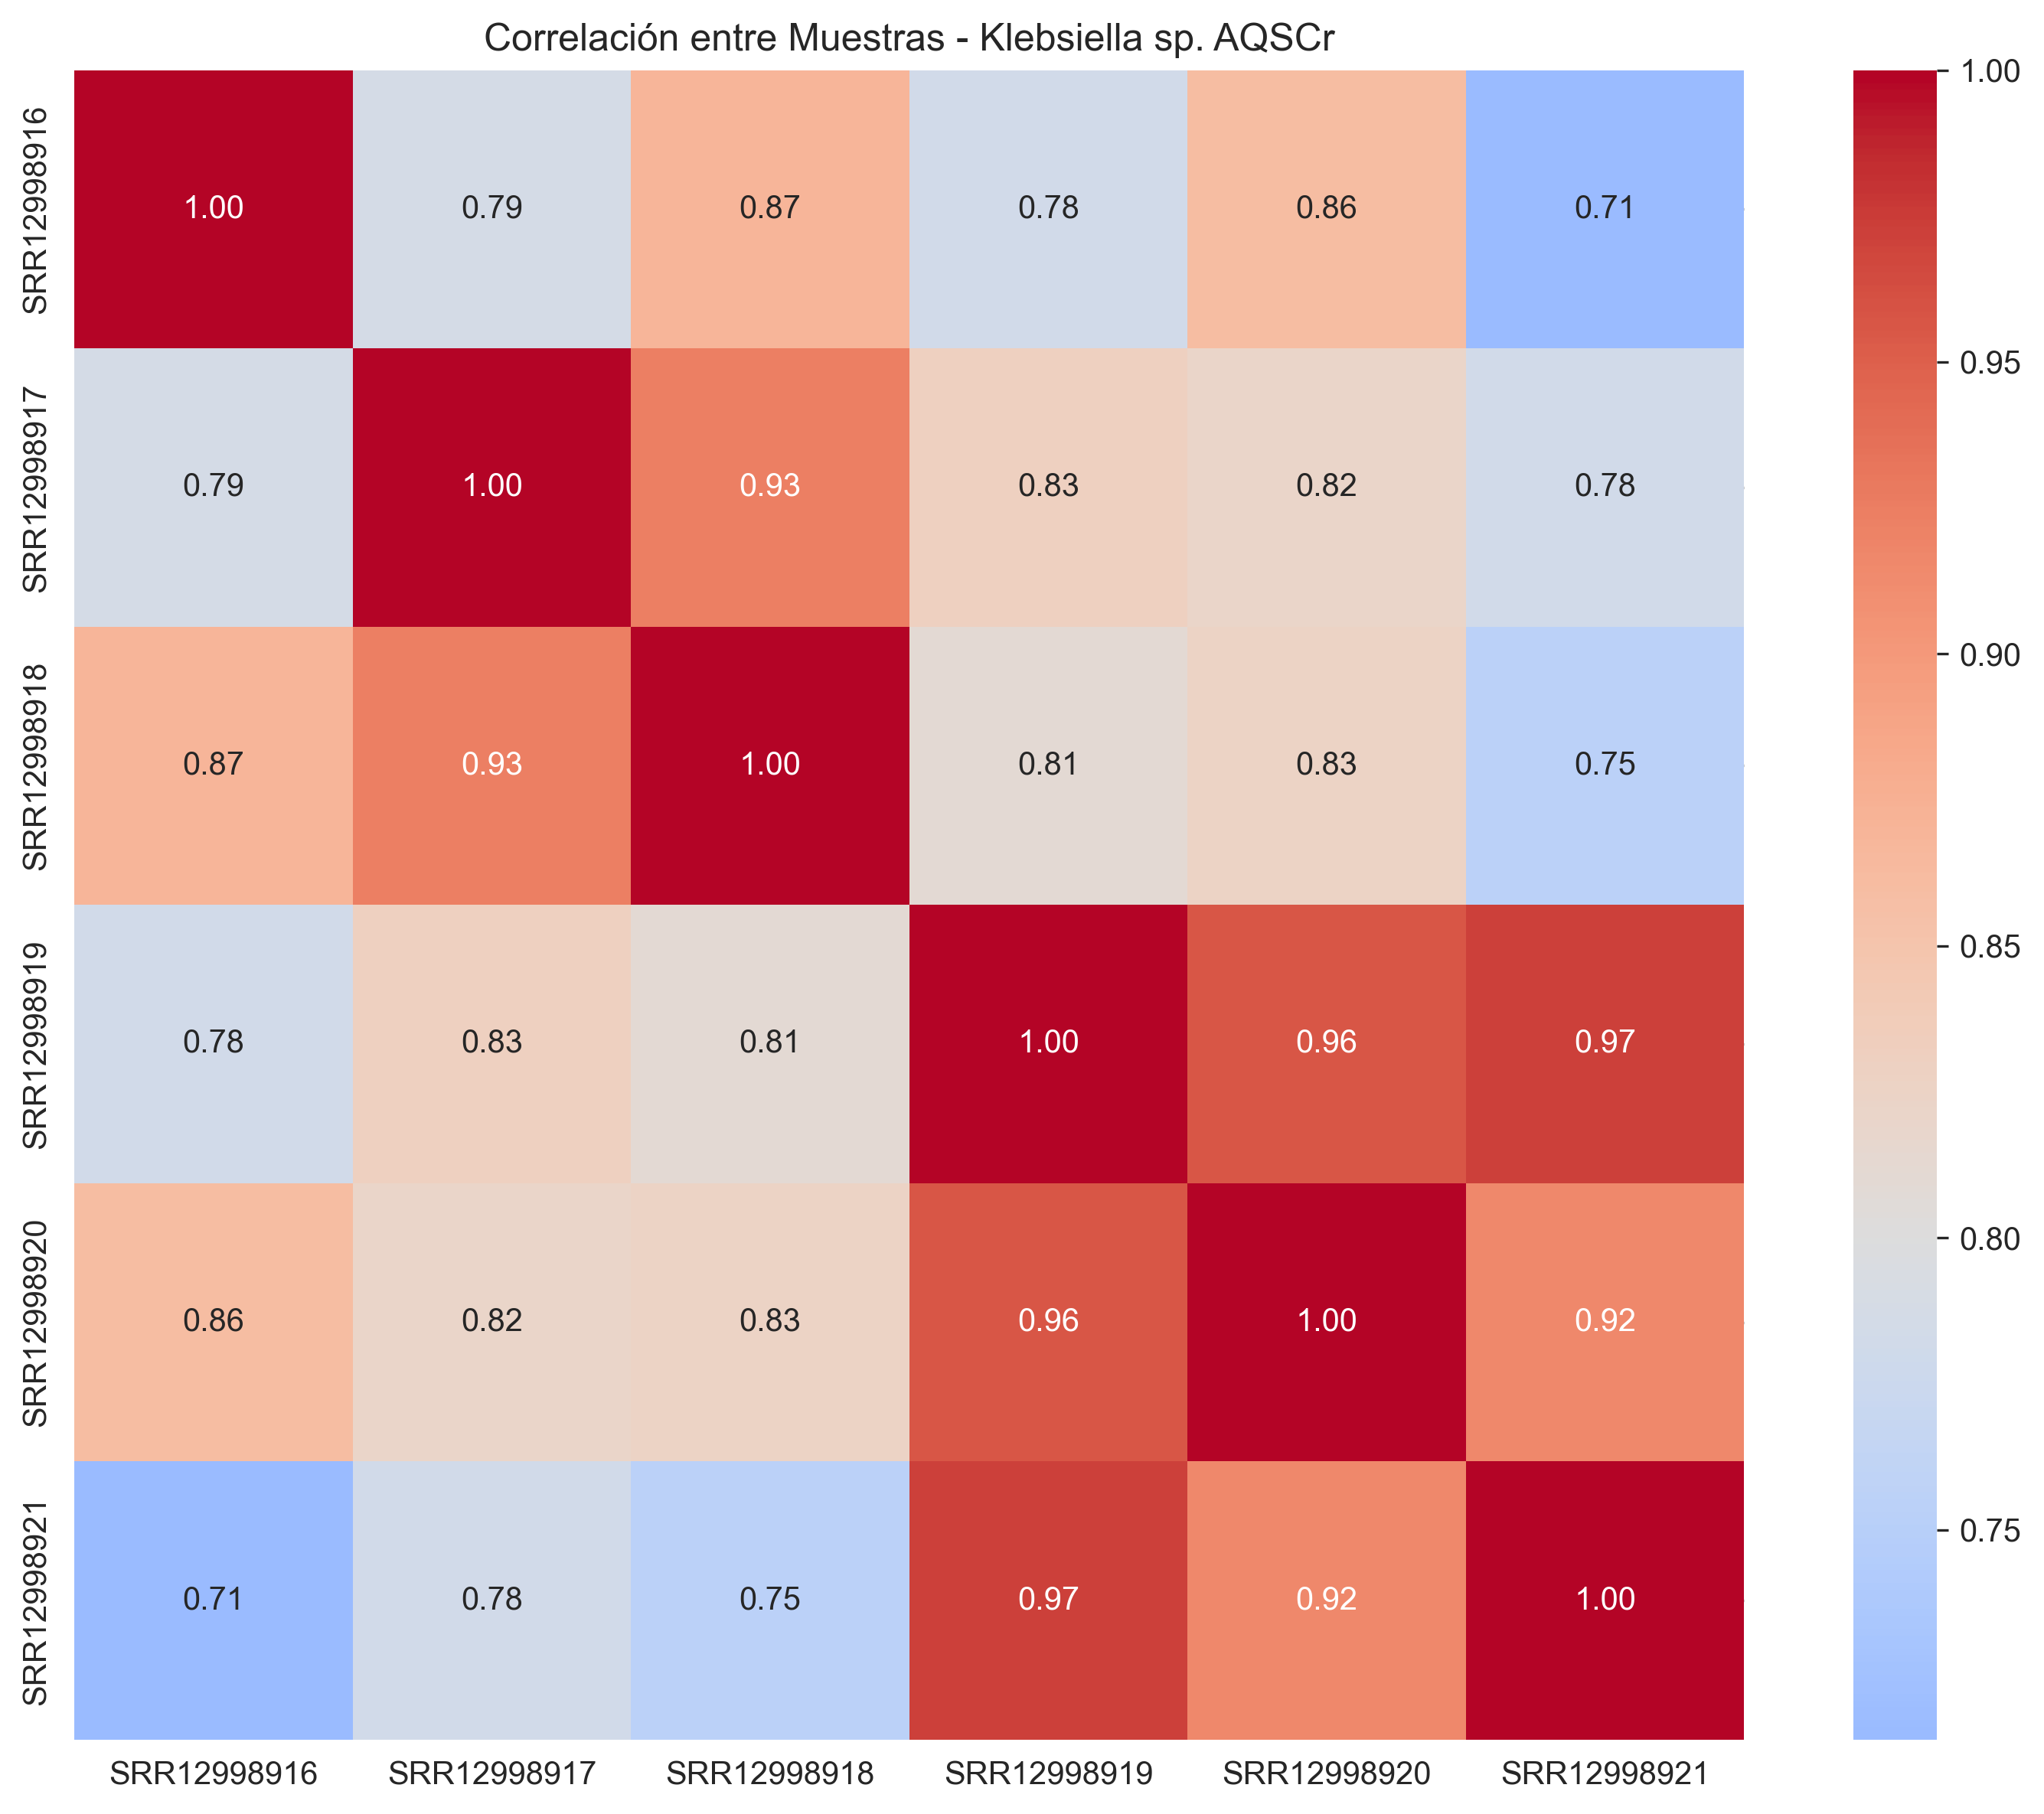

In [13]:

# 2. Usar el nombre correcto de la columna
# En tu archivo es 'Geneid', no 'GeneId'
counts_data = counts_df.set_index('Geneid')

# 3. Calcular matriz de correlación entre muestras
corr_matrix = counts_data.corr()

# 4. Graficar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,           # Mostrar valores
    fmt='.2f',            # Formato 2 decimales
    cmap='coolwarm',      # Colores azul-rojo
    center=0.8,           # Centro del color map
    square=True           # Celdas cuadradas
)
plt.title('Correlación entre Muestras - Klebsiella sp. AQSCr')
plt.tight_layout()
plt.show()

C:\Users\yeimi\AppData\Local\Temp\ipykernel_2016\2254349731.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


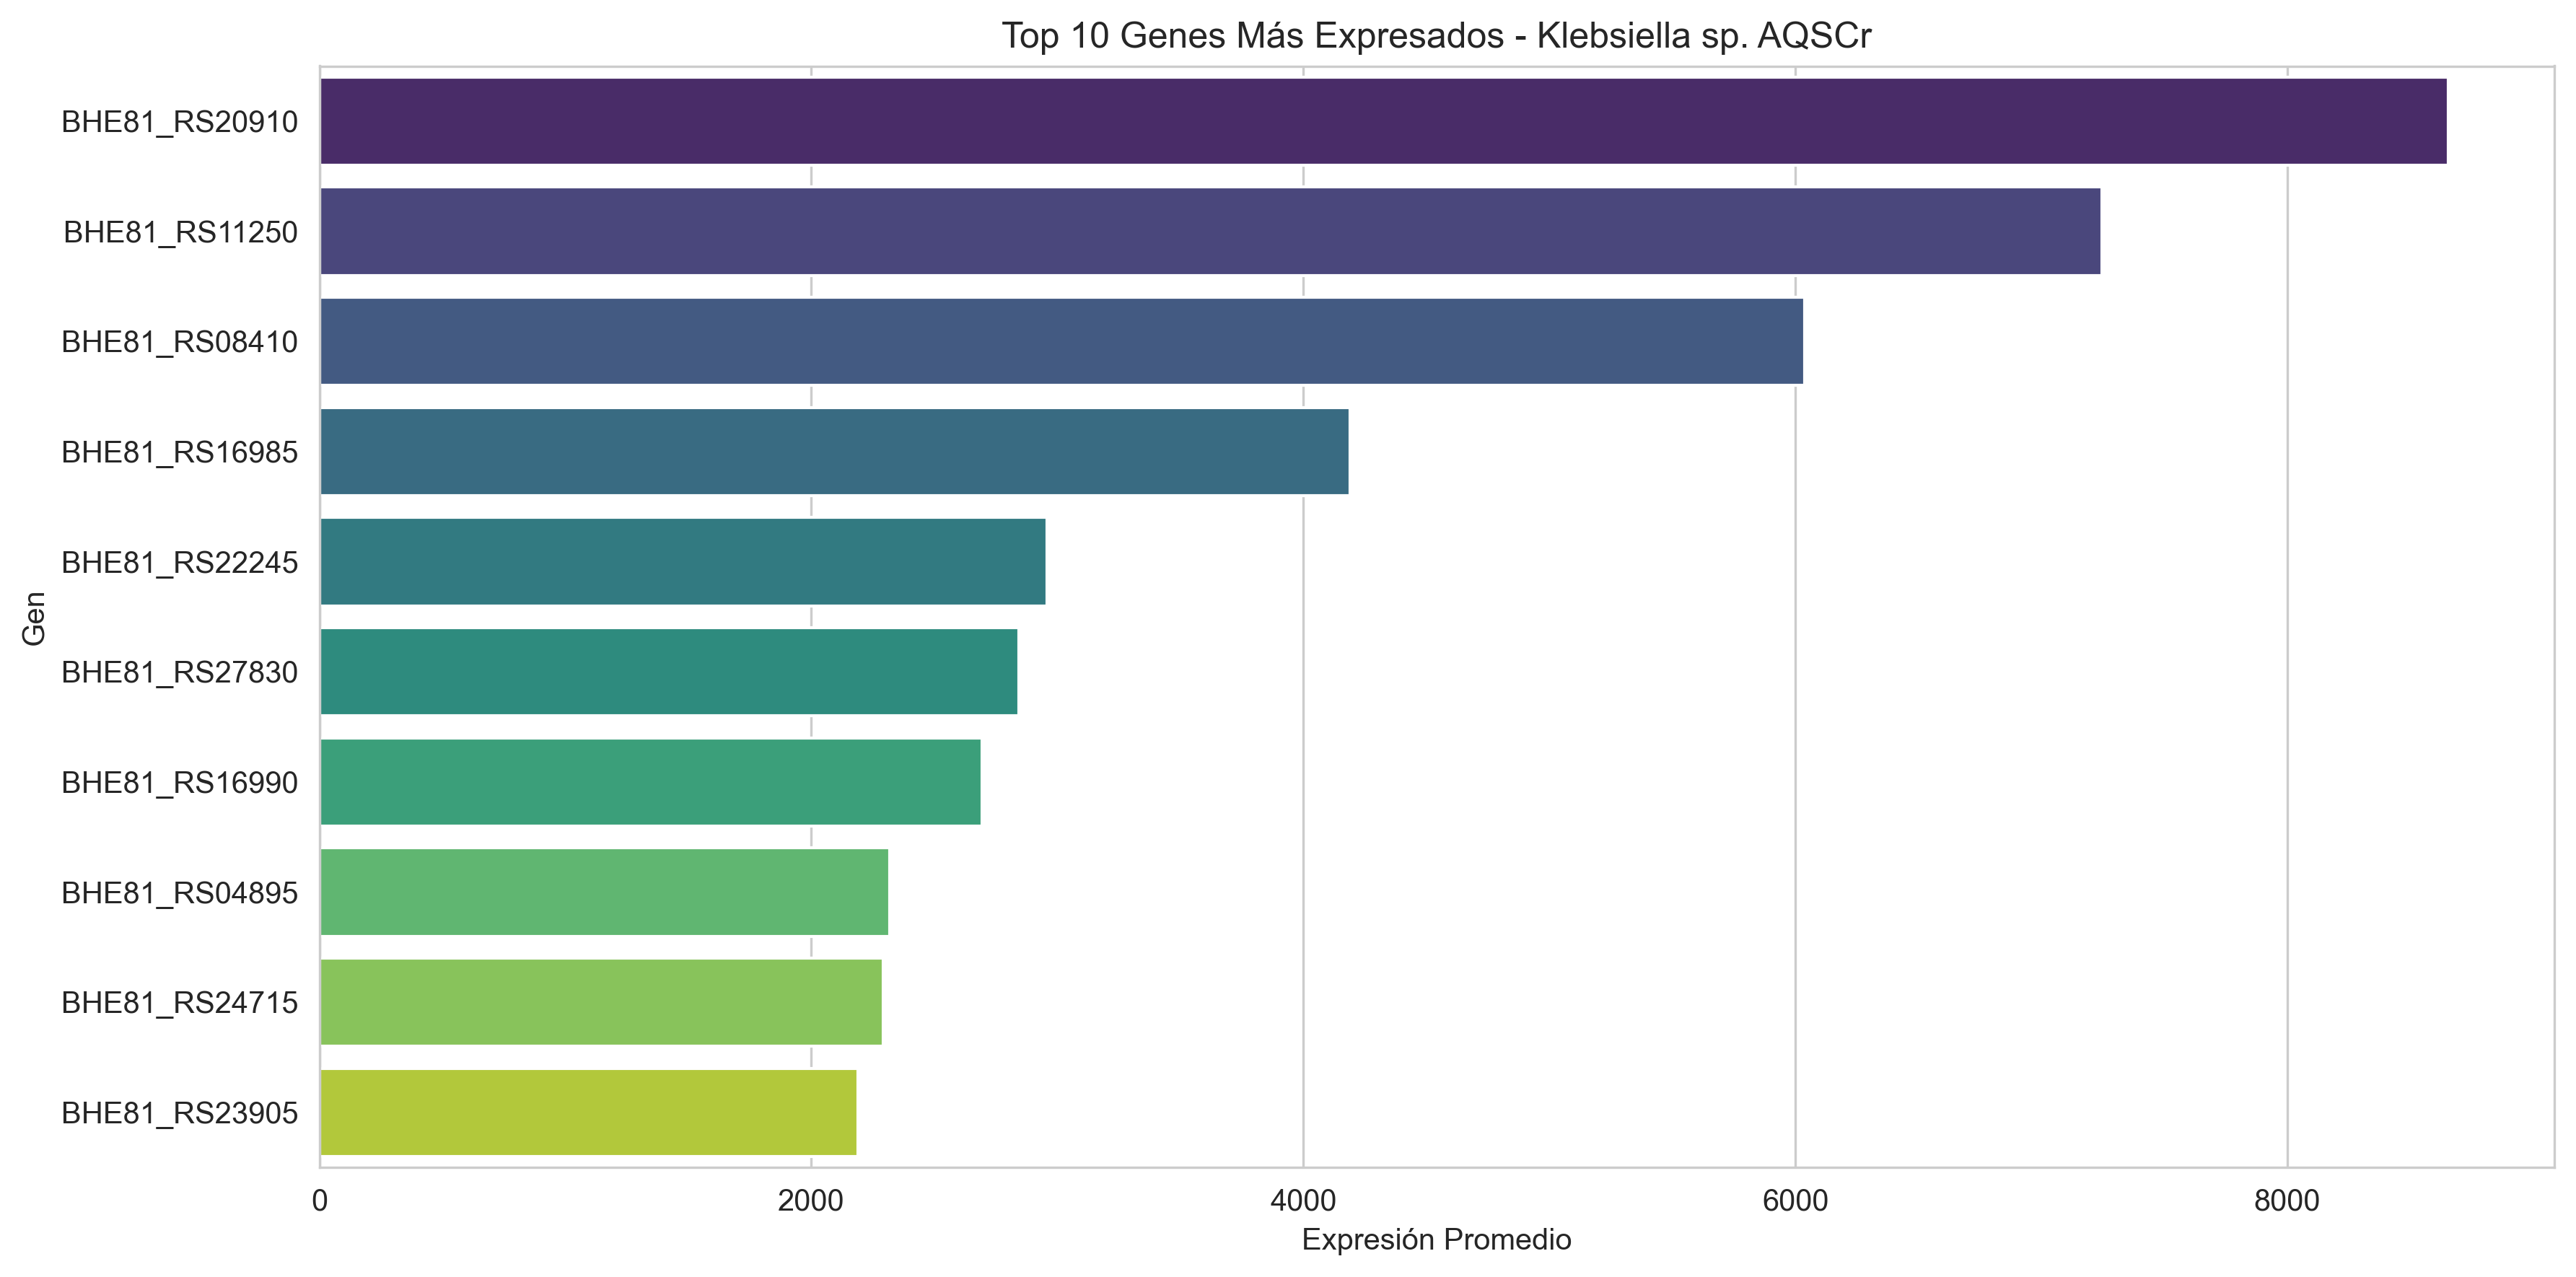

In [14]:

# 2. Usar el nombre correcto de la columna
counts_data = counts_df.set_index('Geneid')

# 3. Calcular expresión promedio por gen
mean_expression = counts_data.mean(axis=1)

# 4. Top 10 genes más expresados
top_10 = mean_expression.nlargest(10).reset_index()
top_10.columns = ['Gene', 'Mean_Expression']

# 5. Graficar barplot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10,
    x='Mean_Expression',
    y='Gene',
    palette='viridis'
)
plt.title('Top 10 Genes Más Expresados - Klebsiella sp. AQSCr')
plt.xlabel('Expresión Promedio')
plt.ylabel('Gen')
plt.tight_layout()
plt.show()

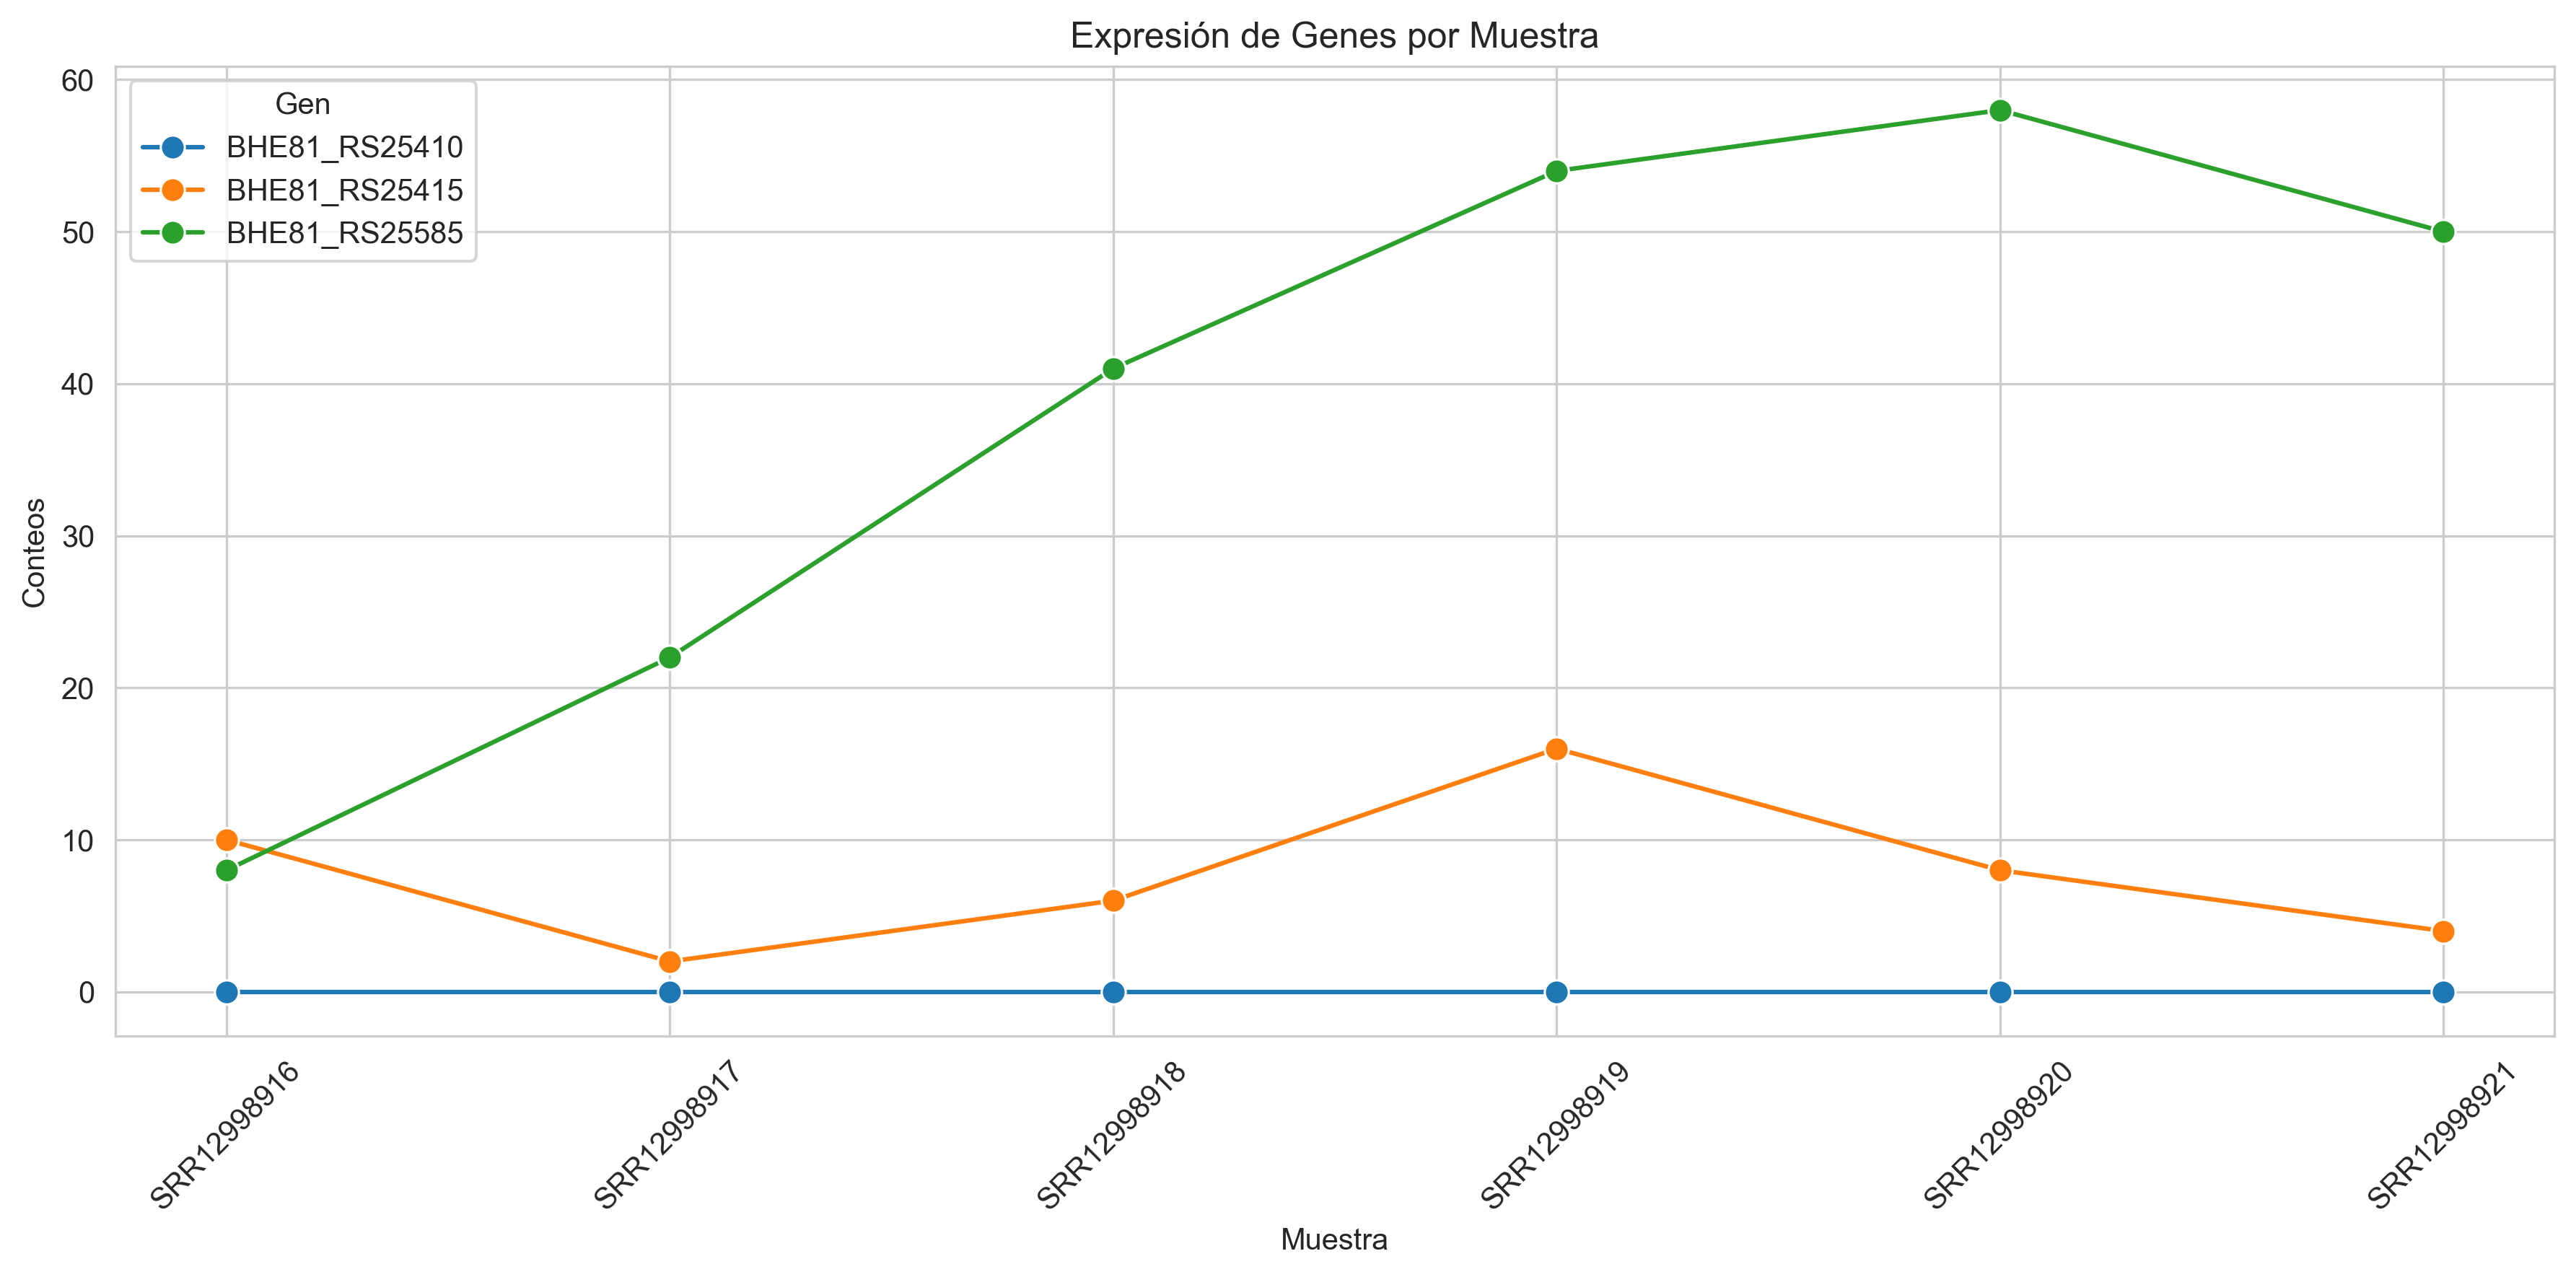

In [23]:

# Tomar 3 genes de ejemplo
genes_ejemplo = counts_df['Geneid'].head(3)

# Preparar datos para lineplot
line_data = counts_df[counts_df['Geneid'].isin(genes_ejemplo)]
line_data = line_data.melt(id_vars=['Geneid'], var_name='sample', value_name='count')
line_data = line_data.merge(design_df, on='sample')

# Graficar lineplot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=line_data,
    x='sample',
    y='count',
    hue='Geneid',
    marker='o',
    markersize=8
)
plt.title('Expresión de Genes por Muestra')
plt.xlabel('Muestra')
plt.ylabel('Conteos')
plt.xticks(rotation=45)
plt.legend(title='Gen')
plt.tight_layout()
plt.show()

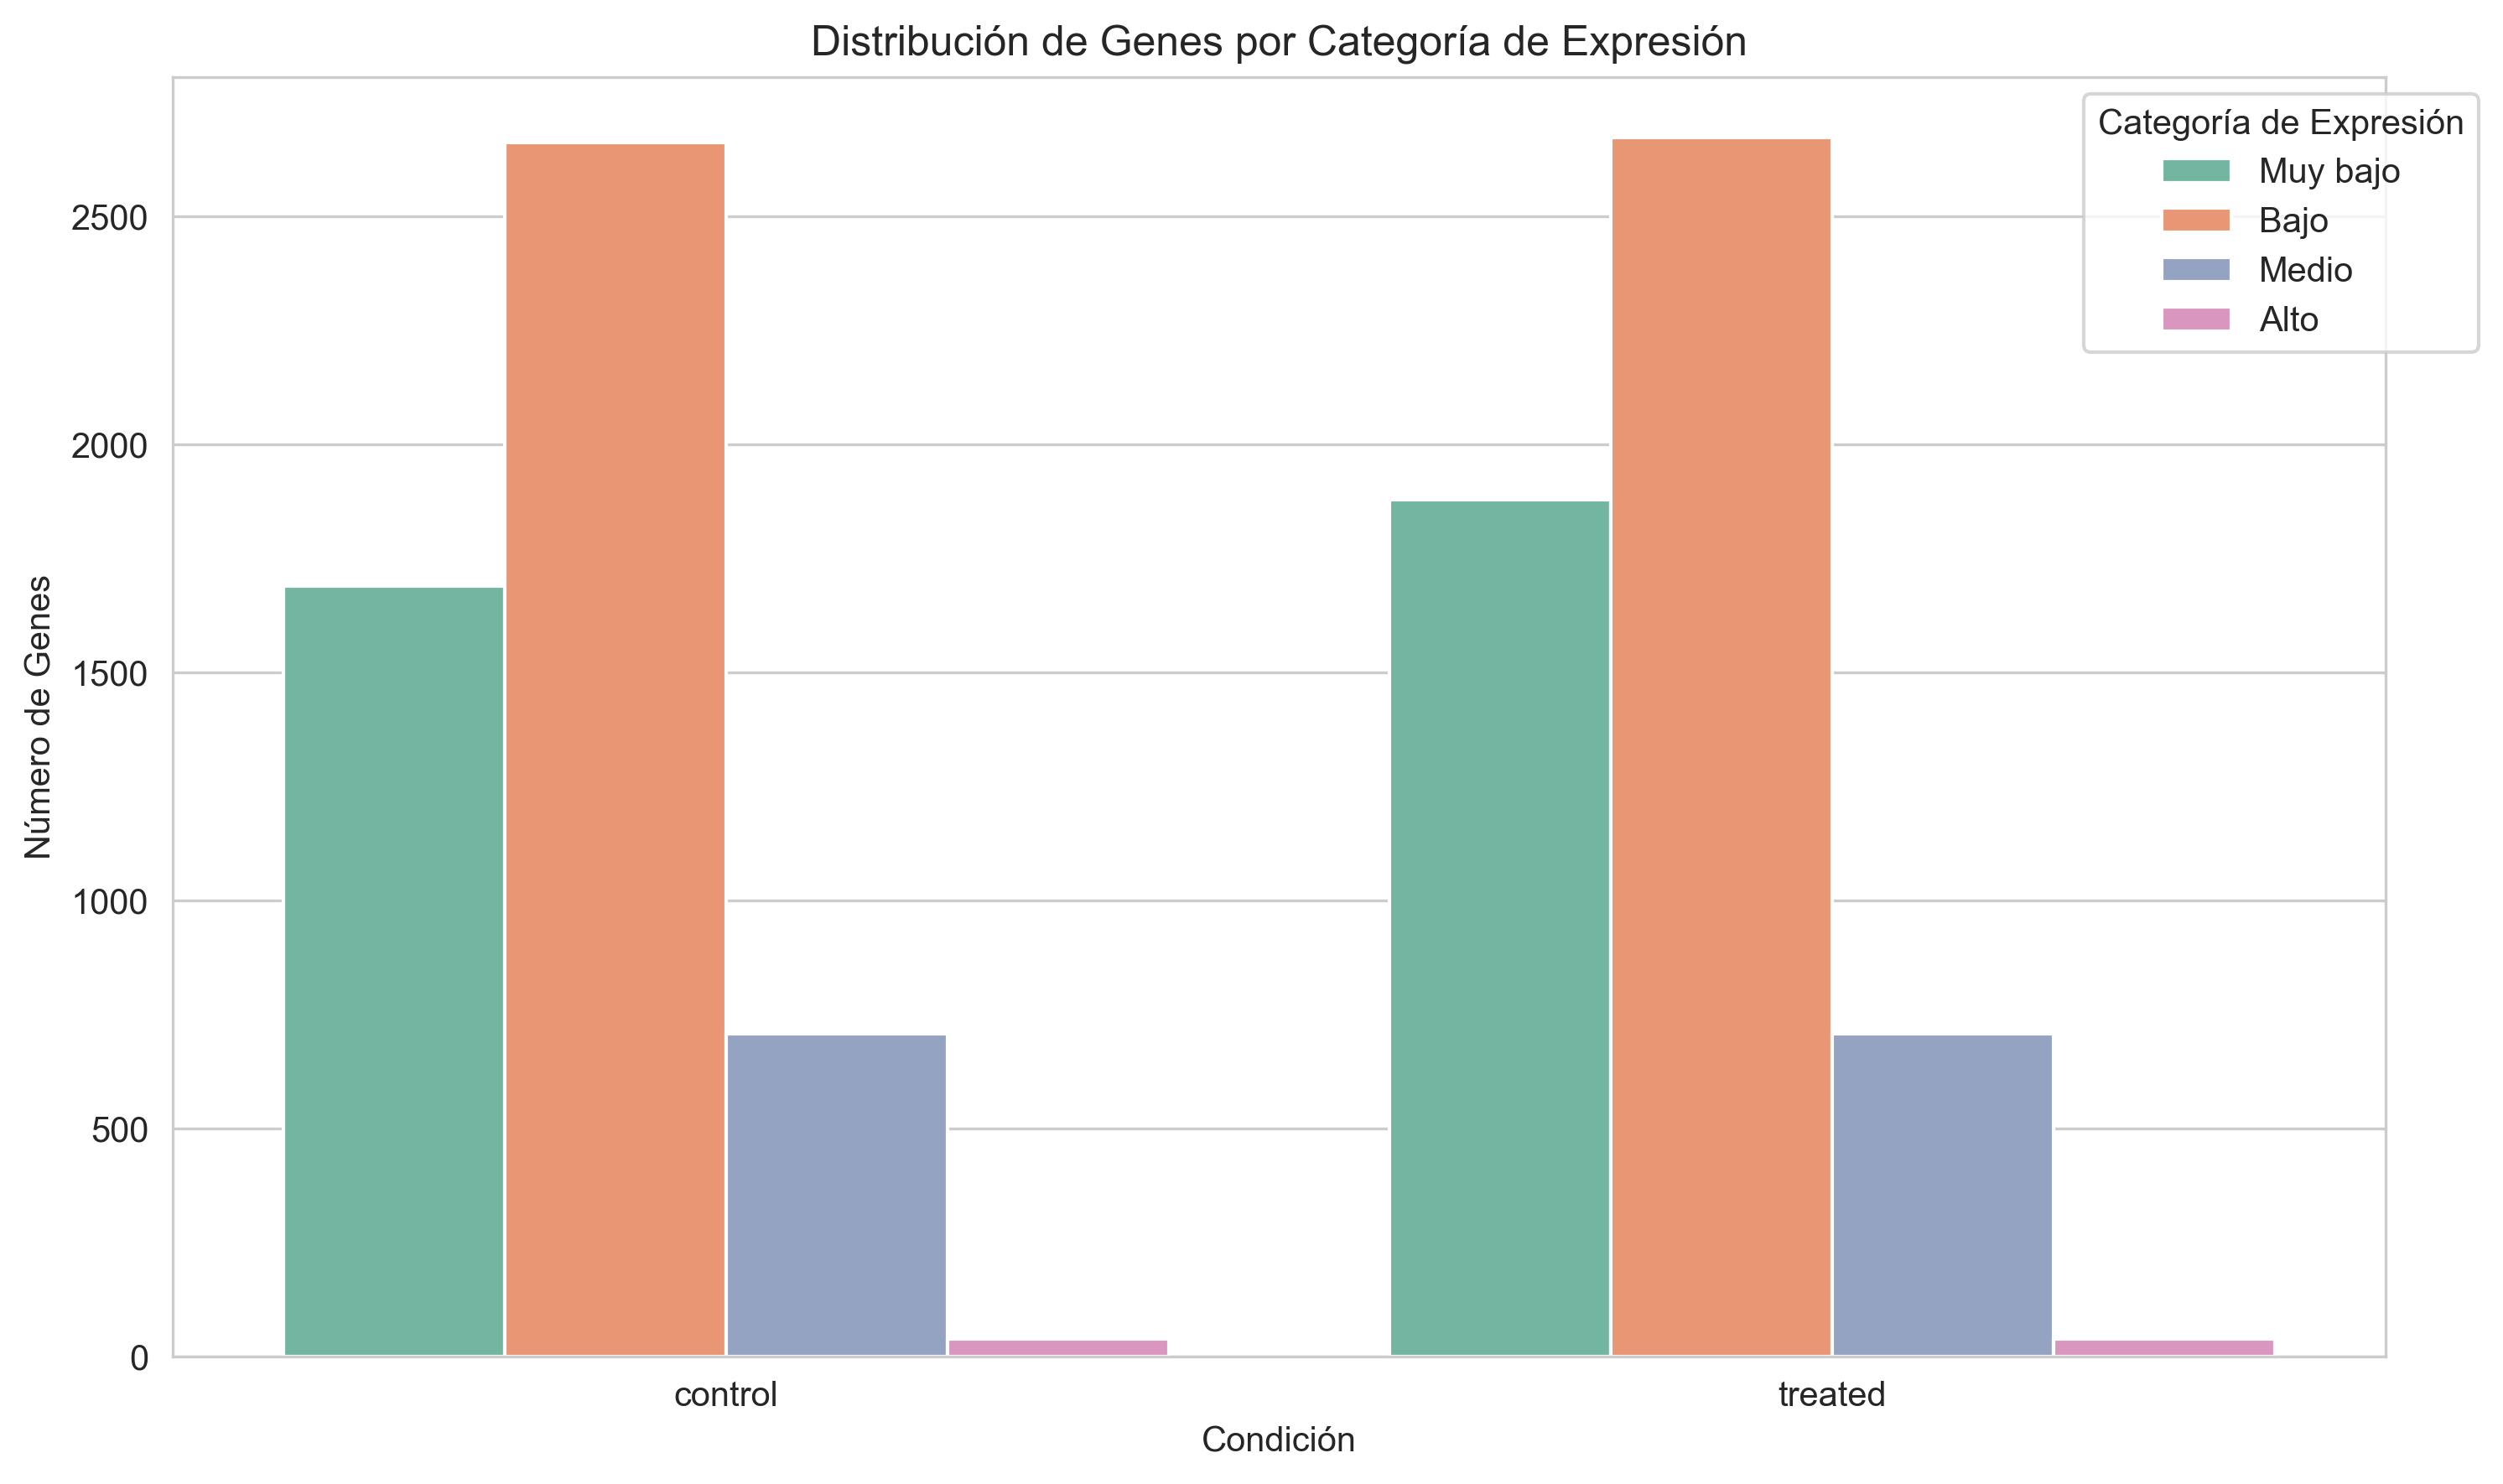

In [24]:

# Usar el nombre correcto de la columna
counts_data = counts_df.set_index('Geneid')

# Calcular expresión promedio por gen
mean_expression = counts_data.mean(axis=1)

# Crear categorías
bins = [0, 10, 100, 1000, float('inf')]
labels = ['Muy bajo', 'Bajo', 'Medio', 'Alto']
counts_data['categoria'] = pd.cut(mean_expression, bins=bins, labels=labels)

# Contar genes por categoría y condición
categoria_counts = []
for condition in design_df['condition'].unique():
    samples = design_df.loc[design_df['condition'] == condition, 'sample']
    # Filtrar solo columnas que existen en counts_data
    samples = [s for s in samples if s in counts_data.columns]
    for categoria in labels:
        # Genes cuya categoría coincide
        mask_categoria = counts_data['categoria'] == categoria
        # Genes expresados (>0 en promedio dentro de esa condición)
        mask_expresados = counts_data[samples].mean(axis=1) > 0
        count = (mask_categoria & mask_expresados).sum()
        categoria_counts.append({
            'condition': condition,
            'categoria': categoria,
            'count': count
        })

# Convertir a DataFrame
stack_data = pd.DataFrame(categoria_counts)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=stack_data,
    x='condition',
    y='count',
    hue='categoria',
    palette='Set2'
)

plt.title('Distribución de Genes por Categoría de Expresión')
plt.ylabel('Número de Genes')
plt.xlabel('Condición')
plt.legend(title='Categoría de Expresión', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

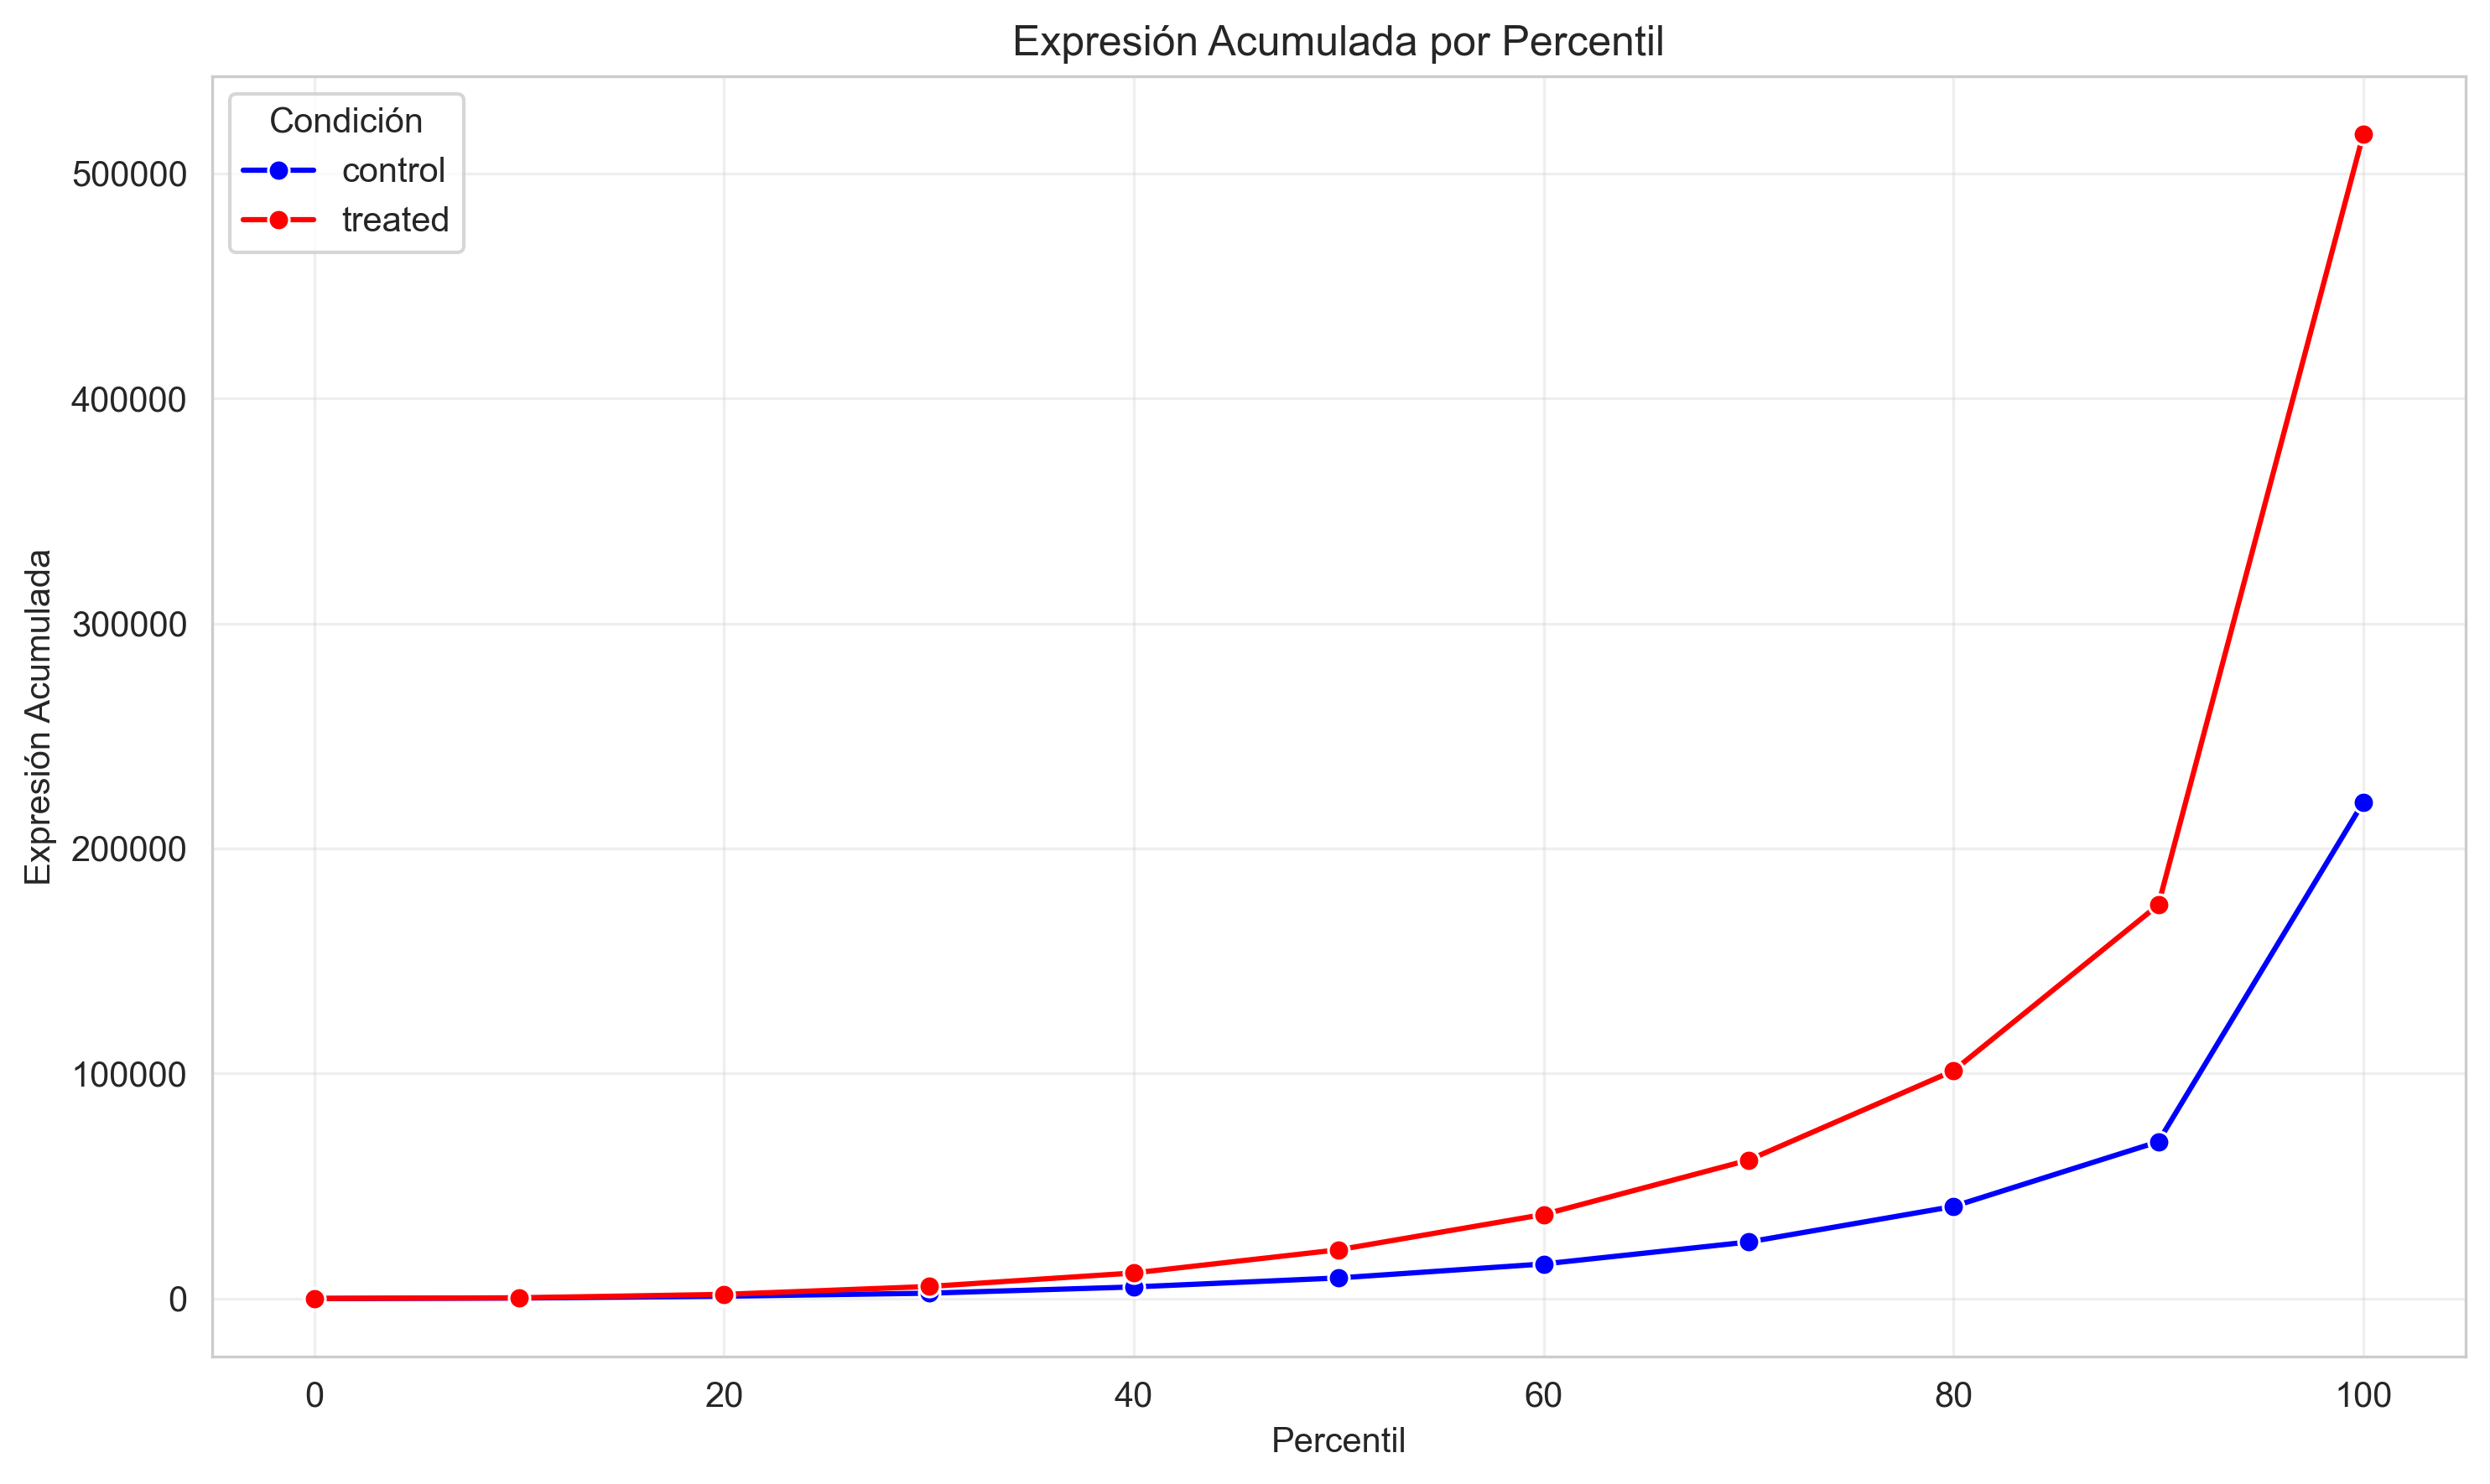

In [25]:

# Usar el nombre correcto de la columna
counts_data = counts_df.set_index('Geneid')

# Definir percentiles
percentiles = np.arange(0, 101, 10)
accum_data = []

# Calcular expresión acumulada por percentil y condición
for condition in design_df['condition'].unique():
    samples = design_df.loc[design_df['condition'] == condition, 'sample']
    # Filtrar solo columnas que existen en counts_data
    samples = [s for s in samples if s in counts_data.columns]
    
    condition_data = counts_data[samples].mean(axis=1)
    
    for p in percentiles:
        threshold = np.percentile(condition_data, p)
        accum_expression = condition_data[condition_data <= threshold].sum()
        accum_data.append({
            'condition': condition,
            'percentile': p,
            'accum_expression': accum_expression
        })

# Convertir a DataFrame
accum_df = pd.DataFrame(accum_data)

# Graficar
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=accum_df,
    x='percentile',
    y='accum_expression',
    hue='condition',
    palette={'control': 'blue', 'treated': 'red'},
    marker='o'
)

plt.title('Expresión Acumulada por Percentil')
plt.xlabel('Percentil')
plt.ylabel('Expresión Acumulada')
plt.grid(True, alpha=0.3)
plt.legend(title='Condición')
plt.tight_layout()
plt.show()